In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# We set a "seed" so that even though it's random, we get the exact same random numbers 
# every time we run the script. (Great for debugging!)
np.random.seed(42)

# 1. Generate Temperatures
# Let's say May in Erlangen has an average (loc) of 15°C, with a spread (scale) of 5°C.
# We will generate 50 days of data instead of just 10.
temperatures = np.random.normal(loc=15, scale=5, size=50)

# 2. Generate Cookie Sales (The Correlated Part)
# Rule: Base sales are 120. For every 1 degree of heat, we lose 3 sales. 
# We also add some random "noise" (standard deviation of 8) because real life isn't perfect.
noise = np.random.normal(loc=0, scale=8, size=50)
cookie_sales = 120 - (3 * temperatures) + noise

# 3. Visualize the new 2D spread (Scatter Plot)
plt.scatter(temperatures, cookie_sales, color='purple', alpha=0.7, edgecolors='black')

plt.title('Simulated Bakery Data: 50 Days')
plt.xlabel('Temperature (°C)')
plt.ylabel('Cookies Sold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# Step 2: Density Estimation (Histogram)
# Let's visualize the "shape" of our temperature distribution

plt.figure(figsize=(10, 4))

# Underfitting (High Bias) - Too few bins
plt.subplot(1, 2, 1)
plt.hist(temperatures, bins=3, color='skyblue', edgecolor='black')
plt.title('Histogram: 3 Bins (High Bias)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency (Count)')

# Overfitting (High Variance) - Too many bins
plt.subplot(1, 2, 2)
plt.hist(temperatures, bins=30, color='salmon', edgecolor='black')
plt.title('Histogram: 30 Bins (High Variance)')
plt.xlabel('Temperature (°C)')

plt.tight_layout()
plt.show()

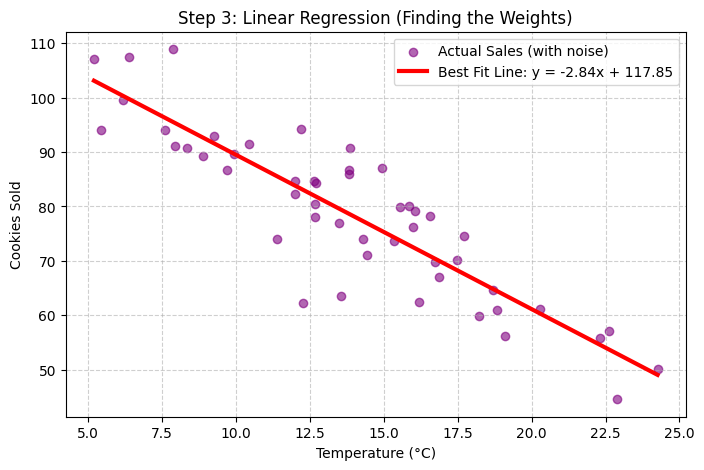

In [14]:
# Step 3: Simple Linear Regression
# We want to find the line (y = mx + b) that minimizes the distance to all our points.

# np.polyfit finds the best slope (m) and intercept (b) for a 1st-degree polynomial (a straight line)
m, b = np.polyfit(temperatures, cookie_sales, 1)

# To draw the line, we create a smooth sequence of X values from our coldest to hottest day
x_line = np.linspace(min(temperatures), max(temperatures), 100)
# Then we calculate the predicted Y values using our new weights
y_line = m * x_line + b

# Let's plot it!
plt.figure(figsize=(8, 5))
# 1. The raw data
plt.scatter(temperatures, cookie_sales, color='purple', alpha=0.6, label='Actual Sales (with noise)')
# 2. The regression line
plt.plot(x_line, y_line, color='red', linewidth=3, label=f'Best Fit Line: y = {m:.2f}x + {b:.2f}')

plt.title('Step 3: Linear Regression (Finding the Weights)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Cookies Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

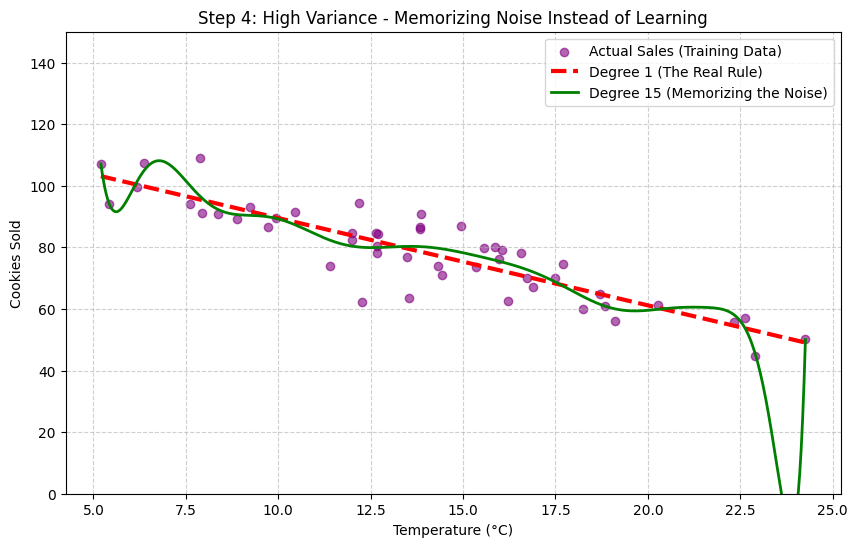

In [13]:
# Step 4: The Bias-Variance Tradeoff (Overfitting)
#import warnings
# Sometimes Numpy warns us when we do something mathematically crazy on purpose!
#warnings.simplefilter('ignore', np.RankWarning) 

# We fit a 15th-degree polynomial (a highly complex model)
complex_weights = np.polyfit(temperatures, cookie_sales, 15)
complex_model = np.poly1d(complex_weights)

# Generate a very smooth line so we can see all the crazy curves
x_smooth = np.linspace(min(temperatures), max(temperatures), 500)
y_smooth = complex_model(x_smooth)

# Let's plot the "Real Rule" vs the "Memorized Noise"
plt.figure(figsize=(10, 6))
plt.scatter(temperatures, cookie_sales, color='purple', alpha=0.6, label='Actual Sales (Training Data)')

# 1. The simple line from Step 3 (Low Variance, well-generalized)
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=3, label='Degree 1 (The Real Rule)')

# 2. The highly complex line (High Variance, overfitted)
plt.plot(x_smooth, y_smooth, color='green', linewidth=2, label='Degree 15 (Memorizing the Noise)')

# Let's zoom in on a sensible y-axis range so the chart doesn't break
plt.ylim(0, 150)

plt.title('Step 4: High Variance - Memorizing Noise Instead of Learning')
plt.xlabel('Temperature (°C)')
plt.ylabel('Cookies Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

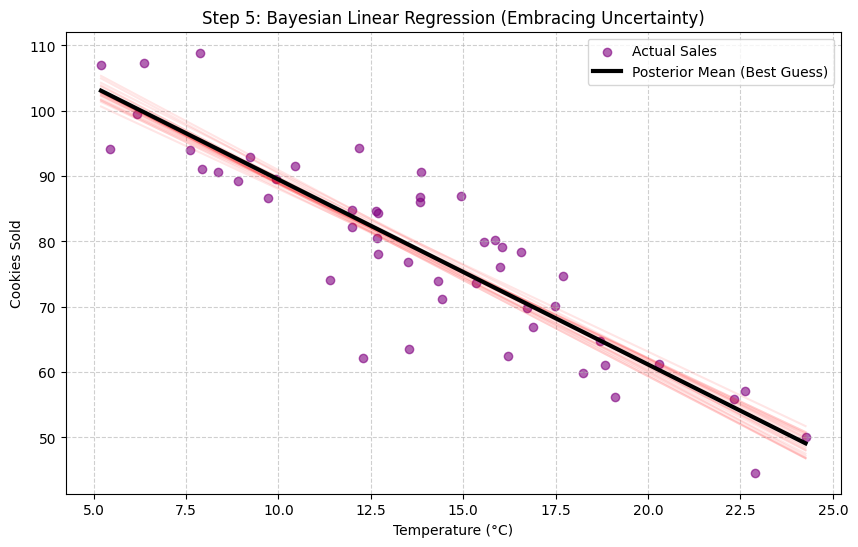

In [12]:
# Step 5: Bayesian Linear Regression
from scipy.stats import norm

# 1. Prepare the Data (Matrix format for the math)
# We add a column of 1s to our temperatures to act as the "intercept" (b)
X = np.vstack((temperatures, np.ones(len(temperatures)))).T
Y = cookie_sales

# 2. Define our Hyperparameters (The Bayesian part)
alpha = 0.0001  # Precision of our Prior (How strongly we believe our initial guess)
beta = 0.05  # Precision of our Likelihood (How much we trust our noisy data)

# 3. Calculate the Posterior Distribution (Closed-form solution)
# This is the exact math from the slides: S_N = (alpha*I + beta*X^T*X)^-1
identity_matrix = np.eye(2)
S_N = np.linalg.inv(alpha * identity_matrix + beta * X.T @ X)

# m_N = beta * S_N * X^T * Y  (The new "best guess" weights)
m_N = beta * S_N @ X.T @ Y

# 4. Generate the "Cloud of Uncertainty"
# Instead of one line, we draw 20 possible lines from our Posterior distribution!
plt.figure(figsize=(10, 6))
plt.scatter(temperatures, cookie_sales, color='purple', alpha=0.6, label='Actual Sales')

# Draw 20 random samples from our learned weight distribution
np.random.seed(42) # Keep it consistent
for i in range(20):
    # Draw a random slope and intercept based on our Bayesian confidence
    sampled_weights = np.random.multivariate_normal(m_N, S_N)
    
    # Calculate the line for these weights
    y_sample = sampled_weights[0] * x_line + sampled_weights[1]
    
    # Plot it faintly
    plt.plot(x_line, y_sample, color='red', alpha=0.1)

# Plot the "Mean" line (The absolute best guess)
y_mean = m_N[0] * x_line + m_N[1]
plt.plot(x_line, y_mean, color='black', linewidth=3, label='Posterior Mean (Best Guess)')

plt.title('Step 5: Bayesian Linear Regression (Embracing Uncertainty)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Cookies Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()